In [3]:
import pandas as pd

In [4]:
nav = pd.read_csv("02_nav_history_cleaned.csv")

In [5]:
scheme = pd.read_csv("07_scheme_performance_cleaned.csv")

In [8]:
benchmark = pd.read_csv("10_benchmark_indices_cleaned.csv")

In [9]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [10]:
scheme.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [11]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [14]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


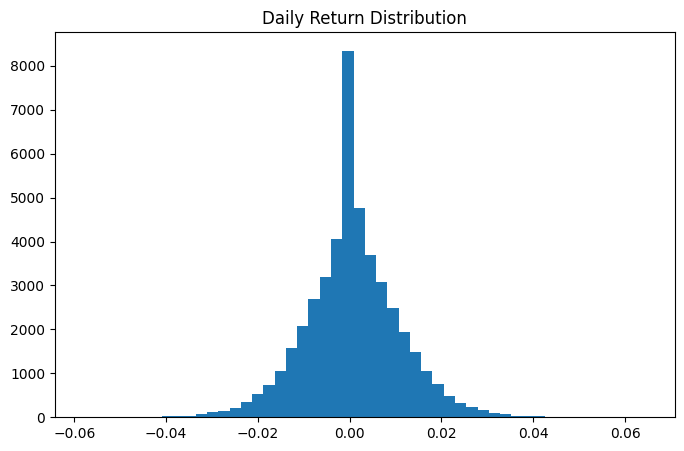

In [15]:
plt.figure(figsize=(8,5))

plt.hist(nav["daily_return"].dropna(),bins=50)

plt.title("Daily Return Distribution")

plt.show()

In [16]:
cagr=[]

for code in nav["amfi_code"].unique():

    temp=nav[nav["amfi_code"]==code]

    start=temp.iloc[0]["nav"]

    end=temp.iloc[-1]["nav"]

    years=(temp["date"].max()-temp["date"].min()).days/365

    value=((end/start)**(1/years))-1

    cagr.append([code,value])

cagr=pd.DataFrame(cagr,columns=["amfi_code","CAGR"])

cagr.sort_values("CAGR",ascending=False).head()

,amfi_code,CAGR
25,120505,0.328016
21,119598,0.323981
39,149324,0.322621
36,148569,0.319245
34,148567,0.309499


In [17]:
risk_free=0.065

sharpe=[]

for code in nav["amfi_code"].unique():

    temp=nav[nav["amfi_code"]==code]

    mean_return=temp["daily_return"].mean()*252

    std=temp["daily_return"].std()*np.sqrt(252)

    ratio=(mean_return-risk_free)/std

    sharpe.append([code,ratio])

sharpe=pd.DataFrame(sharpe,columns=["amfi_code","Sharpe"])

sharpe.sort_values("Sharpe",ascending=False).head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


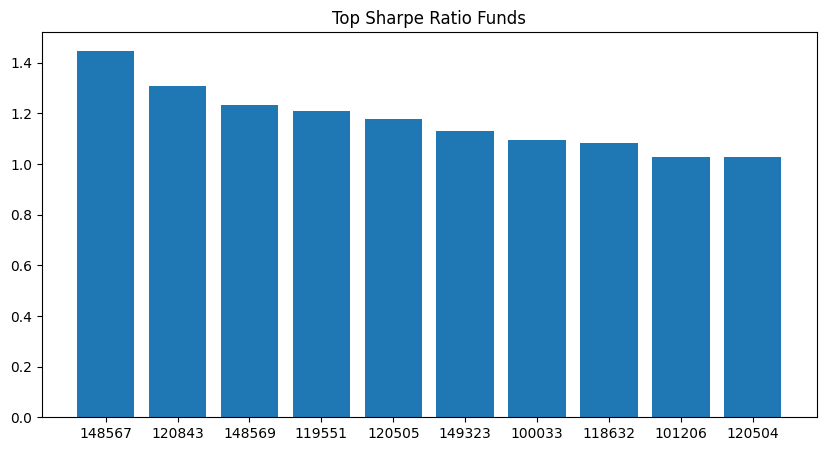

In [18]:
top=sharpe.sort_values("Sharpe",ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top["amfi_code"].astype(str),top["Sharpe"])

plt.title("Top Sharpe Ratio Funds")

plt.show()

In [19]:
sortino=[]

for code in nav["amfi_code"].unique():

    temp=nav[nav["amfi_code"]==code]

    downside=temp[temp["daily_return"]<0]["daily_return"]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=temp["daily_return"].mean()*252

    ratio=(annual_return-risk_free)/downside_std

    sortino.append([code,ratio])

sortino=pd.DataFrame(sortino,columns=["amfi_code","Sortino"])

sortino.sort_values("Sortino",ascending=False).head()

,amfi_code,Sortino
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [20]:
scheme.sort_values("alpha",ascending=False)[["scheme_name","alpha"]].head()

,scheme_name,alpha
9,HDFC Short Term Debt Fund - Regular - Growth,1.98
21,Kotak Emerging Equity Fund - Regular - Growth,1.91
14,ICICI Pru Liquid Fund - Regular - Growth,1.85
22,Kotak Flexicap Fund - Regular - Growth,1.85
29,ABSL Small Cap Fund - Regular - Growth,1.84


In [21]:
scheme.sort_values("beta")[["scheme_name","beta"]].head()

,scheme_name,beta
4,SBI Magnum Gilt Fund - Regular Plan - Growth,0.22
14,ICICI Pru Liquid Fund - Regular - Growth,0.26
19,Nippon India Gilt Securities Fund - Regular - ...,0.37
30,ABSL Liquid Fund - Regular - Growth,0.43
9,HDFC Short Term Debt Fund - Regular - Growth,0.44


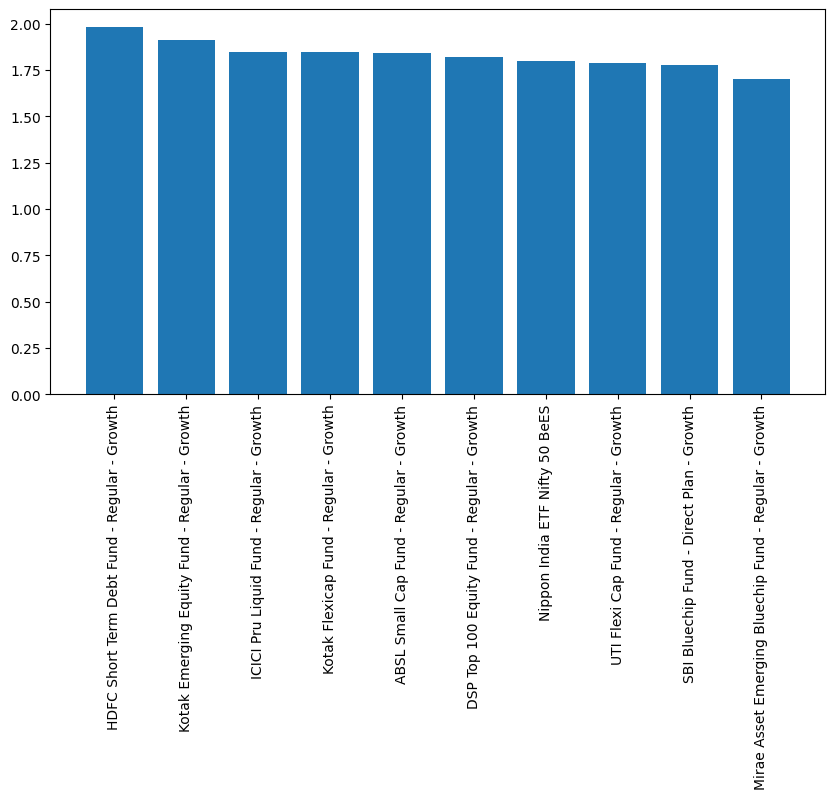

In [22]:
top_alpha=scheme.sort_values("alpha",ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top_alpha["scheme_name"],top_alpha["alpha"])

plt.xticks(rotation=90)

plt.show()

In [24]:
scheme.sort_values("max_drawdown_pct")[["scheme_name","max_drawdown_pct"]].head()

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87


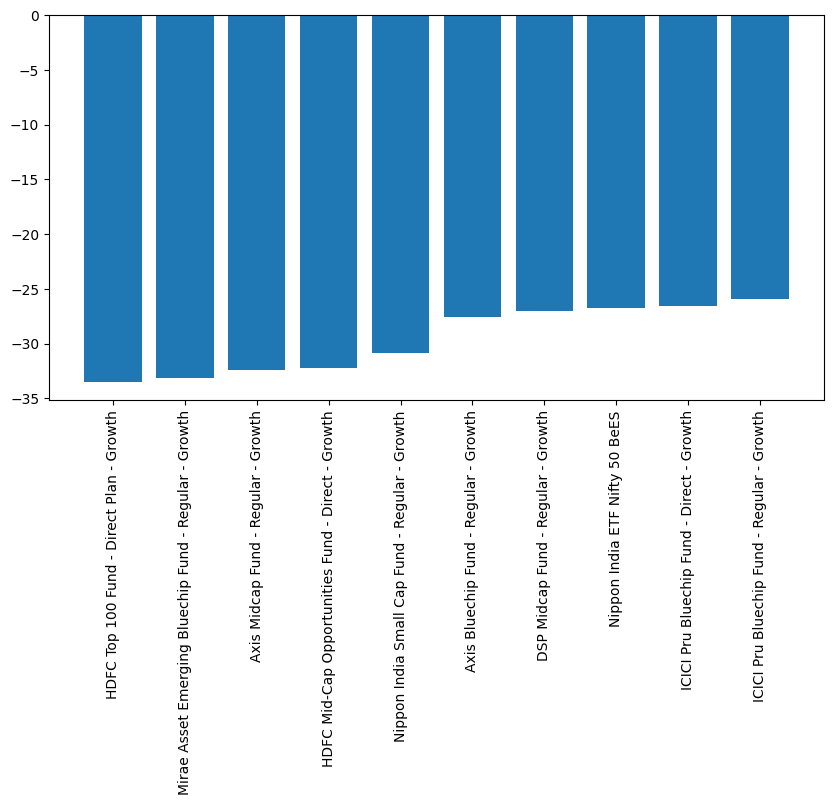

In [25]:
top=scheme.sort_values("max_drawdown_pct").head(10)

plt.figure(figsize=(10,5))

plt.bar(top["scheme_name"],top["max_drawdown_pct"])

plt.xticks(rotation=90)

plt.show()

In [26]:
scheme["return_rank"]=scheme["return_3yr_pct"].rank(ascending=False)

scheme["sharpe_rank"]=scheme["sharpe_ratio"].rank(ascending=False)

scheme["alpha_rank"]=scheme["alpha"].rank(ascending=False)

scheme["expense_rank"]=scheme["expense_ratio_pct"].rank()

scheme["drawdown_rank"]=scheme["max_drawdown_pct"].rank()

In [27]:
scheme["fund_score"]=(
0.30*scheme["return_rank"]+
0.25*scheme["sharpe_rank"]+
0.20*scheme["alpha_rank"]+
0.15*scheme["expense_rank"]+
0.10*scheme["drawdown_rank"]
)

scheme.sort_values("fund_score").head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,2.0,19.5,22.5,5.5,11.0,11.90
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,35012,1.45,5,Moderately High,11.0,12.0,3.5,22.0,21.0,12.40
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,47469,1.56,4,High,7.0,15.0,2.0,33.0,16.0,12.80
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,41613,1.53,5,Very High,3.0,24.5,5.0,28.5,14.0,13.70
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,1.0,18.0,20.0,21.0,33.0,15.25


In [28]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,BSE_SMALLCAP,26554.60
1,2022-01-04,BSE_SMALLCAP,27079.92
2,2022-01-05,BSE_SMALLCAP,27313.35
3,2022-01-06,BSE_SMALLCAP,27377.05
4,2022-01-07,BSE_SMALLCAP,26316.86


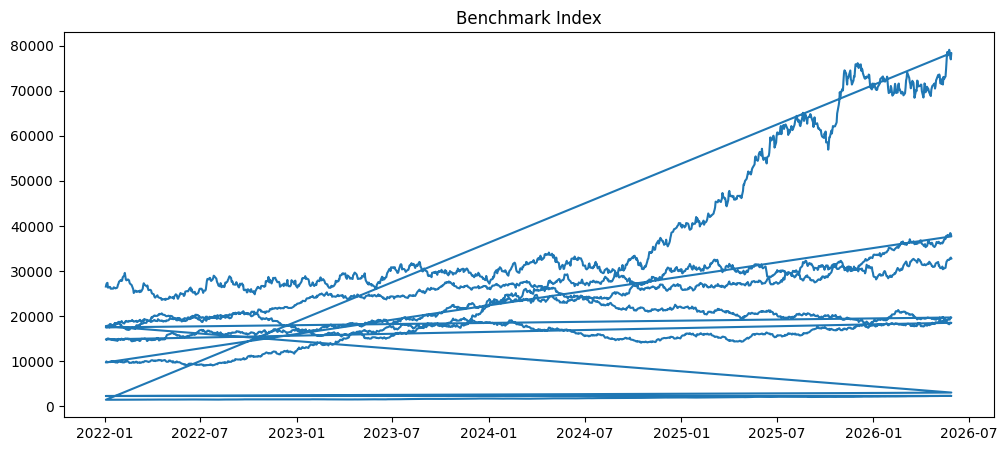

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
benchmark["date"],
benchmark["close_value"]
)

plt.title("Benchmark Index")

plt.show()

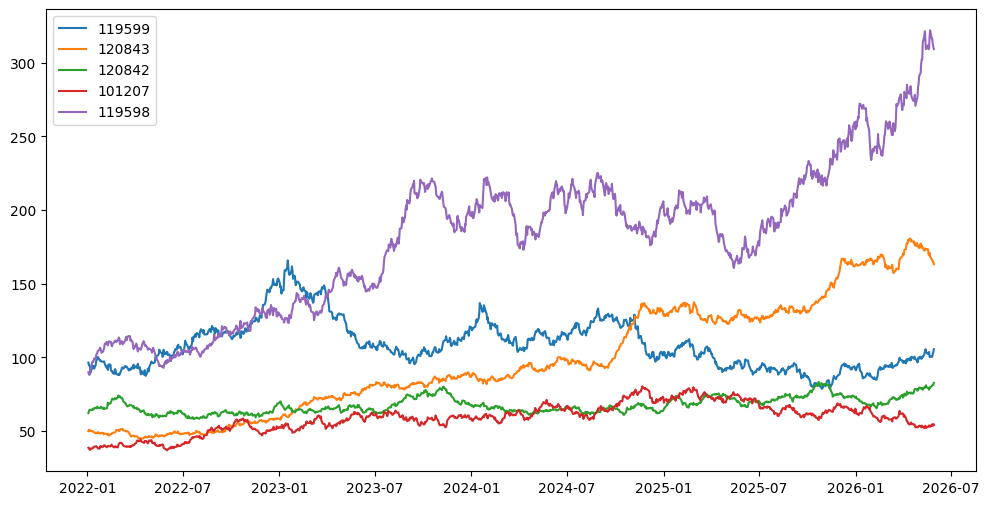

In [30]:
top5=scheme.sort_values("fund_score").head()["amfi_code"]

plt.figure(figsize=(12,6))

for code in top5:

    temp=nav[nav["amfi_code"]==code]

    plt.plot(temp["date"],temp["nav"],label=str(code))

plt.legend()

plt.show()

In [31]:
scheme.to_csv(
"fund_scorecard.csv",
index=False
)

In [32]:
sharpe.to_csv(
"sharpe_ratio.csv",
index=False
)

In [33]:
sortino.to_csv(
"sortino_ratio.csv",
index=False
)

In [34]:
cagr.to_csv(
"cagr.csv",
index=False
)